# [IAPR][iapr]: Project - UNO cards segmentation

**Group ID:** 14

**Author 1 (sciper):** Mario Fernández Blanco (412680)  
**Author 2 (sciper):** Mahdi Fourati (313078)   
**Author 3 (sciper):** Antonin Médéric Hudry (341945)

---

### Imports

In [ ]:
from src.utils import *
from src.dataset_creator import *
import cv2
import numpy as np
import os
import os.path as op
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
from pathlib import Path
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

### Introduction

For this project, we chose to rely on classical segmentation approaches, mainly using Fourier descriptors as a way to classify cards, and morphological operations to segment them. We built an extended reference dataset by manually segmenting the reference images, generating rotated versions of these samples, extracting contours, manually curating them, and then reusing the remaining data.

From these newly created reference images, we extracted Fourier descriptors by detecting contours, filtering them by size, and then interpolating the remaining ones to build a consistent representation. Each contour was converted into a complex signal defined as: $u = x + j y$.

Using these descriptors, we first performed classification with a KNN, and then refined the results through additional filtering to handle special cases and reject contours when they were too far from any known neighbor.

We have three main unresolved problems:

- Holes inside 6, 8, and 9 cards (i.e., the inner regions rather than the outer contours) were often detected as zeros. To mitigate this, we introduced a distance-based filtering step, although this is not fully robust and can sometimes incorrectly remove true zero predictions.
- Skip, zero, and wild cards tend to be assimilated into similar clusters, with zero being the dominant class, which introduces ambiguity in the classification.
- 6 and 9 are 180° rotations of each other, making them inherently difficult to distinguish using shape-based descriptors alone. Despite several attempts, we were unable to reliably separate them, and ultimately defaulted to assigning all such ambiguous cases to the “six” class.

---

### Data extension

To build a KNN classifier, we first needed a set of reference points. The idea here was to simply manually segment all of the reference images to frame properly each card (note that the blue nine is missing, because one corner was damaged unfortunately and so was disrupting the contour detection):

In [2]:
reference_folder = r"reference_images"

references = []
for path in glob(os.path.join(reference_folder, "*")):
    img = cv2.imread(path, cv2.IMREAD_COLOR_RGB)

    if img is not None:
        references.append(img)

In [3]:
r0 = references[0]

one_two_three = r0[600:2490, 1250:2960]

one   = one_two_three[1240:]
two   = one_two_three[640:1270]
three = one_two_three[10:650]

one_yellow, one_red, one_blue, one_green = one[20:,60:400], one[40:,490:840], one[20:-20,940:1290], one[20:-20,1350:-10]
two_yellow, two_red, two_blue, two_green = two[10:,50:390], two[10:,470:820], two[:-20,900:1250], two[:-20,1290:-10]
three_yellow, three_red, three_blue, three_green = three[20:,20:380], three[20:,430:850], three[20:-10,890:1240], three[:-20,1310:-30]

In [4]:
r1 = references[1]

four_five_six = r1[550:2470,1470:3400]

four = four_five_six[1280:]
five = four_five_six[740:1320]
six  = four_five_six[20:700]

four_yellow, four_red, four_blue, four_green = four[40:-20,160:560], four[30:-10,560:950], four[30:-10,1050:1450], four[60:-10,1530:-10]
five_yellow, five_red, five_blue, five_green = five[20:-20,100:460], five[10:-20,550:910], five[10:,1010:1400], five[10:-20,1500:-40]
six_yellow, six_red, six_blue, six_green = six[90:-20,50:420], six[70:-20,490:890], six[60:-60,1000:1360], six[:-70,1450:-70]

In [5]:
r2 = references[2]

seven_eight_nine = r2[600:2550,1700:3680]

seven = seven_eight_nine[1300:]
eight = seven_eight_nine[720:1300]
nine  = seven_eight_nine[30:680]

wild     = r2[1760:2350,1200:1600]
plus4    = r2[880:1520, 1130:1530]

seven_yellow, seven_red, seven_blue, seven_green = seven[90:-20,170:550], seven[70:-30,630:1000], seven[30:-20,1040:1450], seven[30:-70,1550:-60]
eight_yellow, eight_red, eight_blue, eight_green = eight[40:,110:470], eight[20:-20,560:920], eight[30:-10,1020:1380], eight[10:-20,1530:-90]
nine_yellow, nine_red, nine_blue, nine_green = nine[60:-30,40:400], nine[:-50,520:950], nine[40:,1040:1470], nine[:-60,1550:-10]

In [6]:
r3 = references[3]

plus2s   = r3[1700:2300, 100:1800]
reverses = r3[170:920, 1680:3500]
skips    = r3[880:1630, 1730:3670]
zeros    = r3[1570:2270, 1870:3680]

plus2_yellow, plus2_blue, plus2_red, plus2_green = plus2s[:,:400], plus2s[:,450:850], plus2s[:,850:1250], plus2s[:,1250:]
reverse_yellow, reverse_red, reverse_blue, reverse_green = reverses[150:,:400], reverses[100:-30,470:870], reverses[:650,930:1400], reverses[40:650,1420:]
skip_yellow, skip_red, skip_blue, skip_green = skips[140:,50:480], skips[120:-30,470:880], skips[50:700,890:1350], skips[:650,1430:1890]
zero_yellow, zero_red, zero_blue, zero_green = zeros[50:-10,:430], zeros[40:-50,450:870], zeros[10:630,910:1330], zeros[:620,1350:1790]

In [7]:
image_groups = {
    "zero": [zero_blue, zero_green, zero_red, zero_yellow],
    "one": [one_blue, one_green, one_red, one_yellow],
    "two": [two_blue, two_green, two_red, two_yellow],
    "three": [three_blue, three_green, three_red, three_yellow],
    "four": [four_blue, four_green, four_red, four_yellow],
    "five": [five_blue, five_green, five_red, five_yellow],
    "six-nine": [six_blue, six_green, six_red, six_yellow, nine_green, nine_red, nine_yellow],
    "seven": [seven_blue, seven_green, seven_red, seven_yellow],
    "eight": [eight_blue, eight_green, eight_red, eight_yellow],
    "reverse": [reverse_blue, reverse_green, reverse_red, reverse_yellow],
    "skip": [skip_blue, skip_green, skip_red, skip_yellow],
    "plus": [plus2_blue, plus2_green, plus2_red, plus2_yellow, plus4],
    "wild": [wild],
}


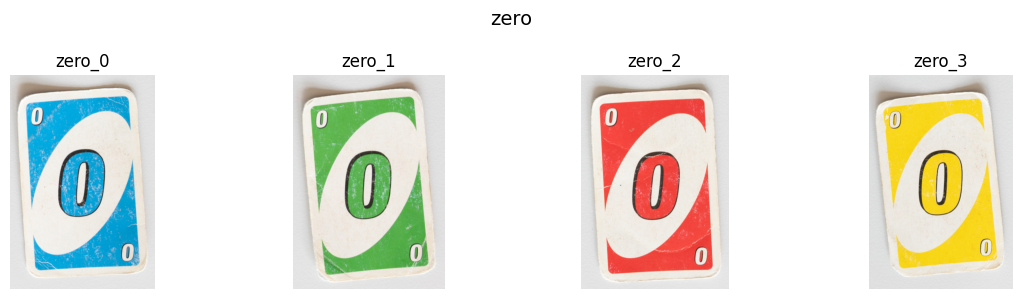

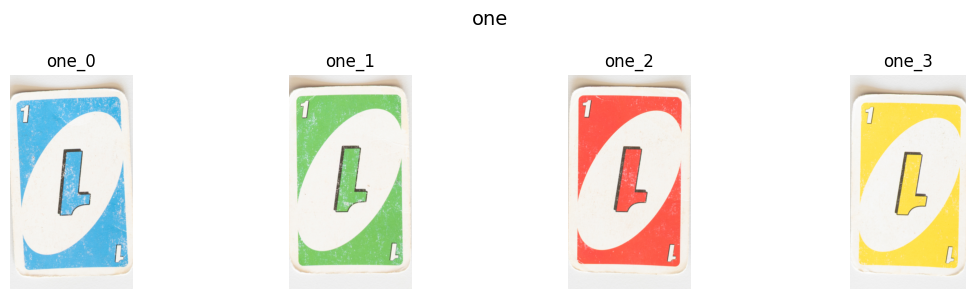

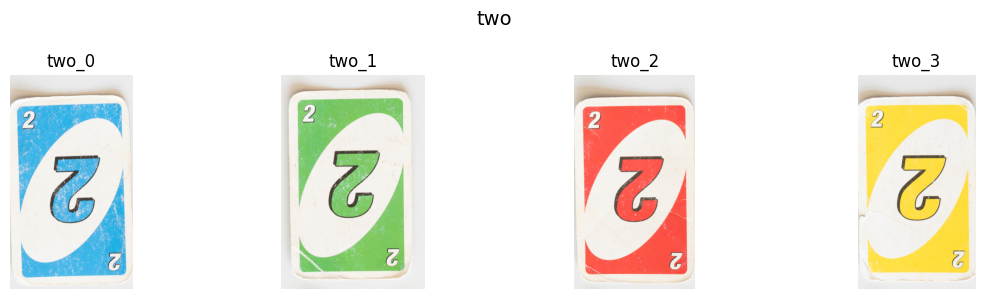

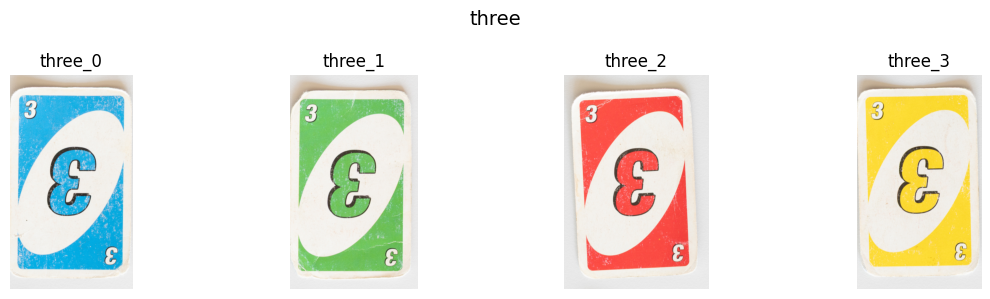

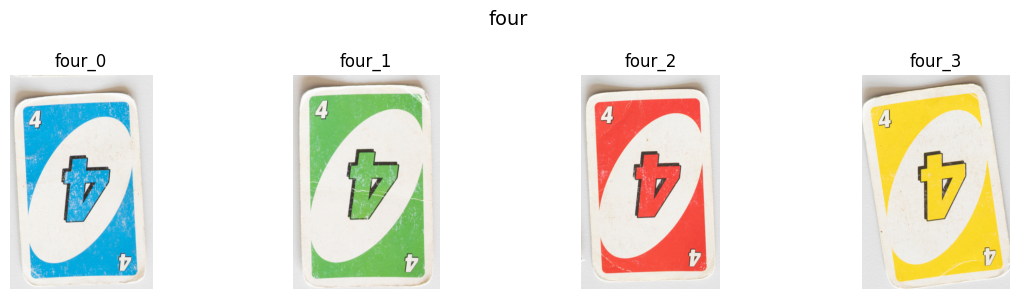

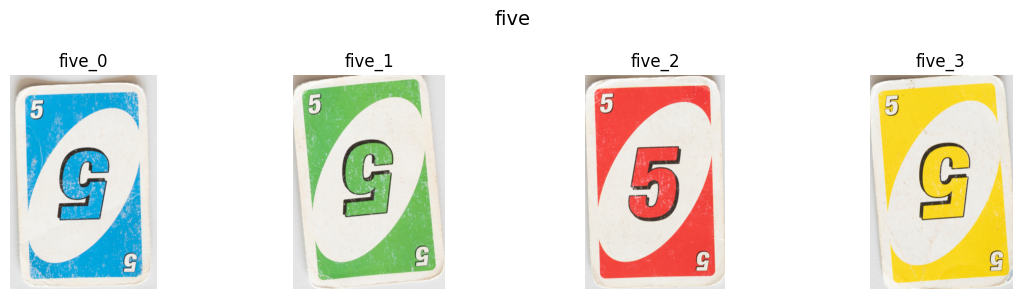

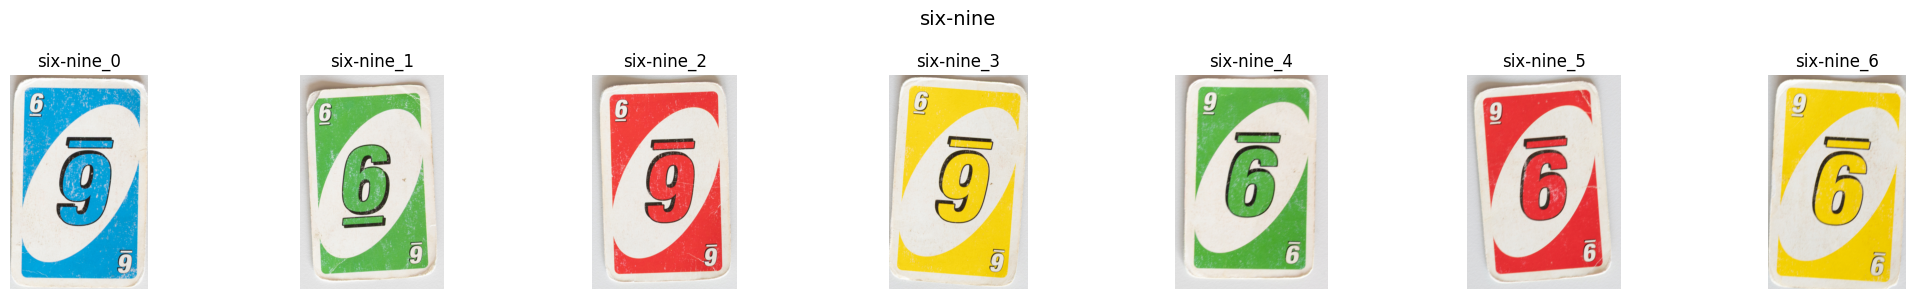

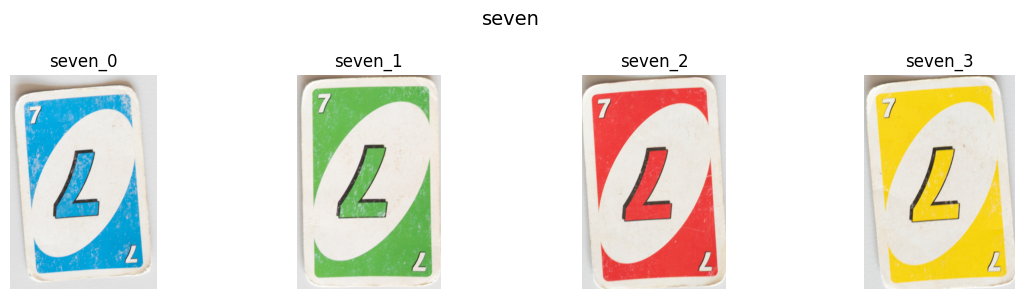

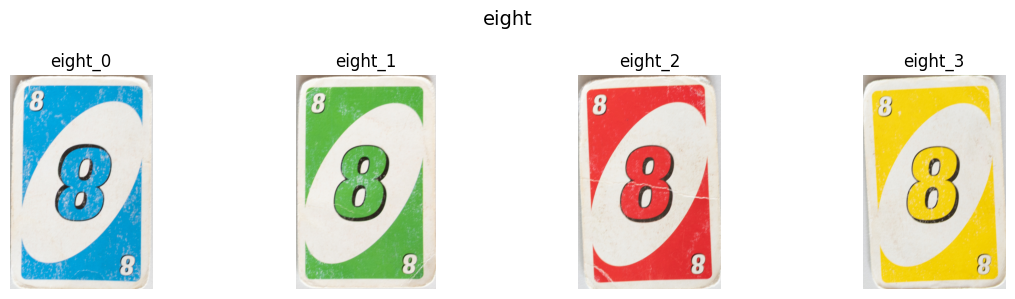

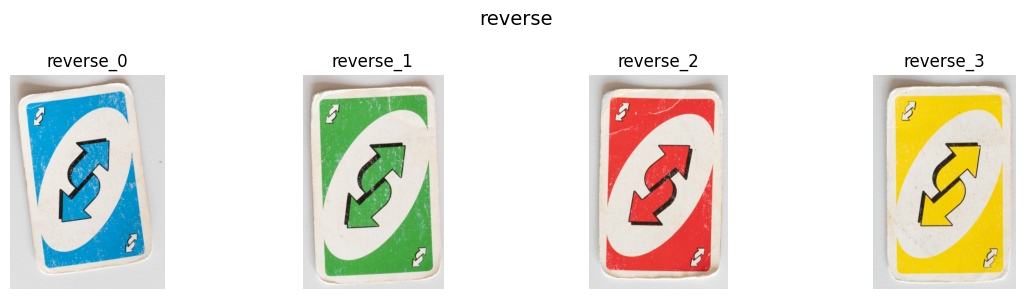

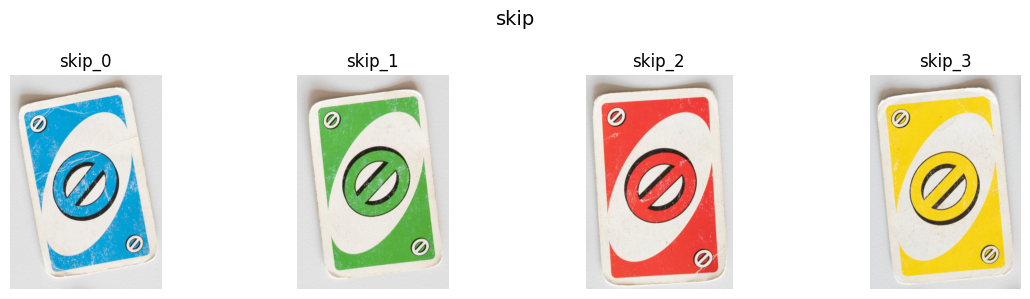

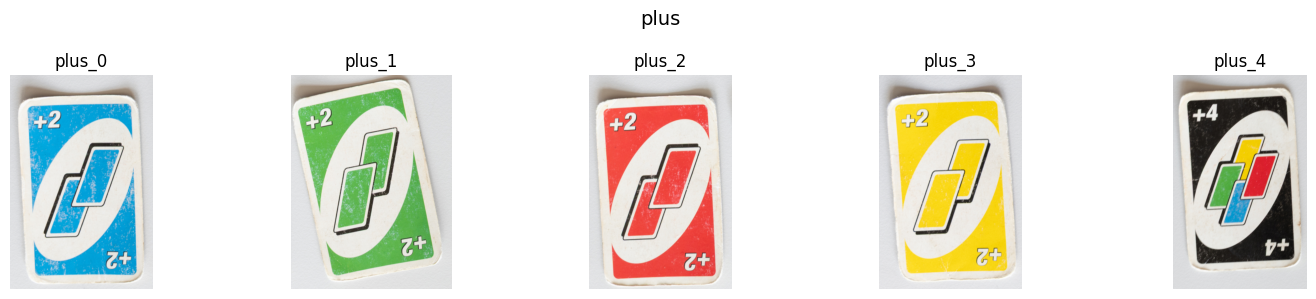

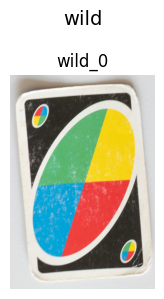

In [8]:
for label, imgs in image_groups.items():

    n = len(imgs)
    fig, axs = plt.subplots(1, n, figsize=(3*n, 3))

    # if only one image (e.g. wild), axs is not a list → fix it
    if n == 1:
        axs = [axs]

    fig.suptitle(label, fontsize=14)

    for i, img in enumerate(imgs):
        axs[i].imshow(img)
        axs[i].set_title(f"{label}_{i}")
        axs[i].axis("off")

    plt.tight_layout()
    plt.show()

---

### Finding cards and contours

The second main task is to actually find the cards in the images and get the contours. The simplest approach is to apply thresholding based on RGB and HSV values

For images with a white background, this step is relatively straightforward, since we can filter out pixels that are sufficiently close to white, which preserves most of the relevant card regions:

In [9]:
def card_only_filter_blank(img):
    return ((img[:,:,0] < 180) |
            (img[:,:,1] < 180) |
            (img[:,:,2] < 180))

For the background with the leaves, the process was slightly more complex, but we managed to find a good threshold on HSV and RGB without damaging the cards too much:

In [10]:
def card_only_filter_leaf(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    rgb_filtered = apply_rgb_threshold(img, r_range=(200,255), g_range=(200,255), b_range=(200,255)) # see utils
    hsv_filtered = (hsv[:,:,0]<25) | ((hsv[:,:,0]<170)&(hsv[:,:,0]>160))
    return ~(rgb_filtered & hsv_filtered)

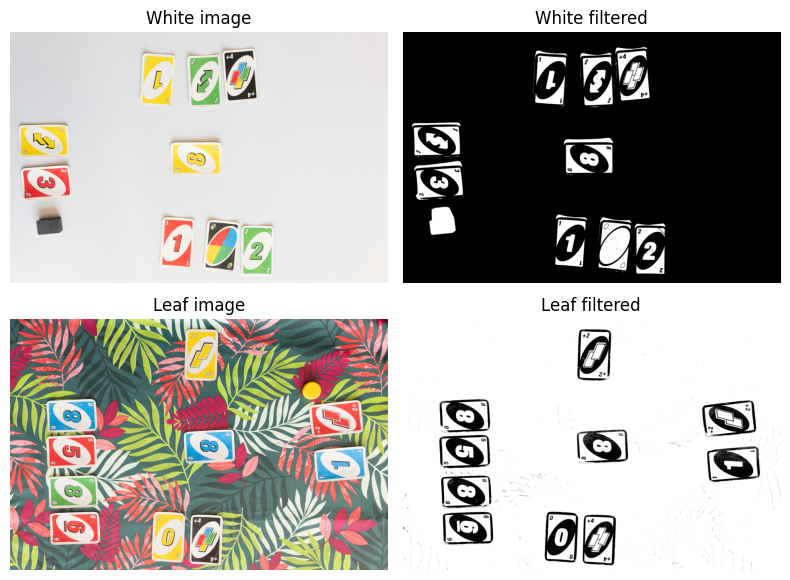

In [11]:
img_white_b = cv2.imread('train_images/L1000773.jpg')
img_leaf_b = cv2.imread('train_images/L1000907.jpg')

img_white = cv2.cvtColor(img_white_b, cv2.COLOR_BGR2RGB)
img_leaf = cv2.cvtColor(img_leaf_b, cv2.COLOR_BGR2RGB)

filtered_white = card_only_filter_blank(img_white_b)
filtered_leaf = card_only_filter_leaf(img_leaf)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0,0].imshow(img_white)
axes[0,0].set_title("White image")

axes[0,1].imshow(filtered_white, cmap='gray')
axes[0,1].set_title("White filtered")

axes[1,0].imshow(img_leaf)
axes[1,0].set_title("Leaf image")

axes[1,1].imshow(filtered_leaf, cmap='gray')
axes[1,1].set_title("Leaf filtered")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

Notice that the filters behave slightly differently, but this is not an issue as long as the digits and pictograms remain visible.

For contour extraction, we use OpenCV’s findContours function with the cv2.RETR_TREE parameter, which allows us to retrieve hierarchical contours and properly detect inner structures across both filtering approaches. Since cards can overlap or be partially occluded, the most reliable strategy for classification is to focus on the outer card contours. We therefore first discard regions that are either too small or too large, then extract contours and further filter them based on minimum and maximum area constraints.

In [12]:
def detect_number_contours(gray, min_area=300, max_area=2200):
    """
    Args:
        img: Input RGB image
        min_area: Minimum contour area (filter out noise)
        max_area: Maximum contour area (filter out large regions)
        
    Returns:
        List of valid card contours, edges, dilated image
    """
    
    
    gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
    gray = ~remove_small_objects(~gray.astype(np.uint8), min_size=min_area).astype(np.uint8)

    contours, _ = cv2.findContours(gray, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    valid_contours = []
    for contour in contours:
        area = cv2.contourArea(contour)
        # Filter by area
        if area < min_area or area > max_area:
            continue
        valid_contours.append(contour)
    
    return valid_contours

def plot_contours(image, contours, color=(0, 255, 0), thickness=2):
    """
    Draw contours returned by cv2.findContours.
    """

    if len(image.shape) == 2:
        output = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    else:
        output = image.copy()
        
    cv2.drawContours(output, contours, -1, color, thickness)

    plt.figure(figsize=(8, 8))
    plt.imshow(output)
    plt.axis("off")
    plt.show()

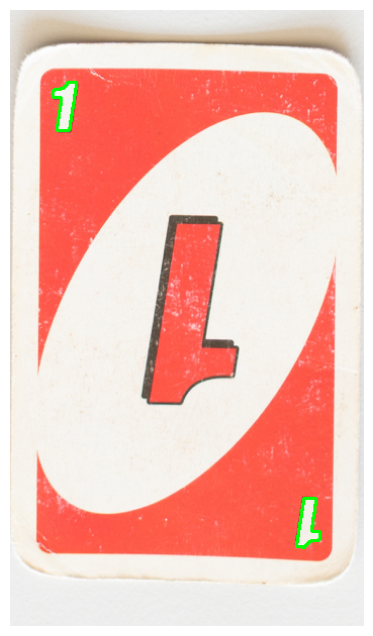

In [13]:
test_img = one_red
filter_img = card_only_filter_blank(test_img)
valid_contours_test = detect_number_contours(filter_img)
_ = plot_contours(test_img, valid_contours_test)

---

### Fourier descriptors

As mentioned in the introduction, the goal is to build a rotated dataset and compute Fourier descriptors of the pictograms located in the card corners, which will later serve as the neighborhood for the KNN classifier (explained below). Below, we construct the dataset used to define this neighborhood, consisting of all manually cropped reference images, with each image rotated in 9° increments up to 180°:

In [14]:
datasets = {}
all_images = {}
all_contours = {}

for label, imgs in image_groups.items():

    rotated_imgs, contours, descriptors = build_rotated_descriptor_dataset(imgs, label, n_rotations=21, angle_step=9)

    all_images[label] = rotated_imgs
    all_contours[label] = contours

    datasets[label] = np.concatenate(descriptors, axis=0)

Then we applied the same procedure as in Lab 2 of this course to the contours of the corner pictograms, including interpolation and descriptor normalization. Note that we enforce invariance to rotation and translation, but not to scaling, since in theory all cards are expected to have the same size:

In [15]:
def fourier_descriptors(contours, n_samples=100, interpolation=True):
    """
    Compute translation and rotation invariant Fourier descriptors.
    
    Parameters
    ----------
    contours : list of (K,2) arrays
    n_samples : int
    interpolation : bool

    Returns
    -------
    descriptors : (N, n_samples-1)
        Translation + rotation invariant descriptors.

    centers : (N, 2)
        Contour centroids.

    rotations : (N,)
        Dominant contour orientation in radians.
    """

    descriptors = []
    centers = []
    rotations = []

    for contour in contours:

        contour = np.asarray(contour.squeeze(), dtype=np.float64)
        
        d = np.sqrt(np.sum(np.diff(contour, axis=0)**2, axis=1))
        t = np.concatenate([[0], np.cumsum(d)])

        t_new = np.linspace(0, t[-1], n_samples)
        x = np.interp(t_new, t, contour[:, 0])
        y = np.interp(t_new, t, contour[:, 1])

        contour = np.stack([x, y], axis=1)
        
        center = contour.mean(axis=0)
        centers.append(center)

        z = contour[:, 0] + 1j * contour[:, 1]
        fd = np.fft.fft(z)
        fd[0] = 0

        rotation = np.angle(fd[1])
        rotations.append(rotation)
        fd *= np.exp(-1j * rotation)
        descriptors.append(np.abs(fd[1:]))

    return (
        np.array(descriptors),
        np.array(centers),
        np.array(rotations)
    )

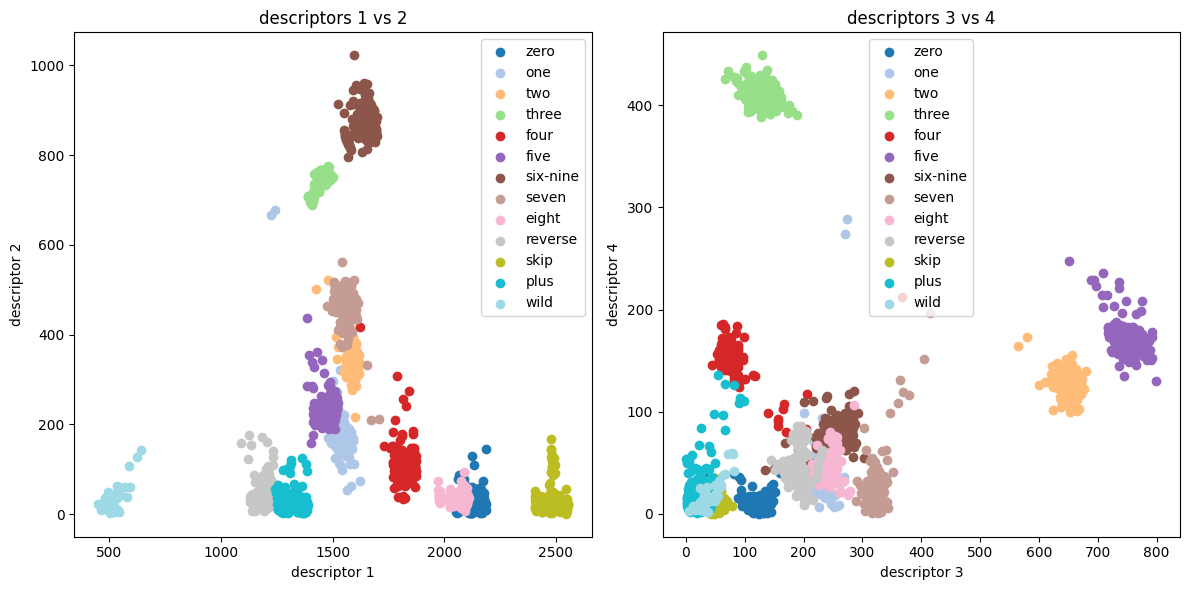

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

colors = plt.cm.tab20(np.linspace(0, 1, len(datasets)))

for (label, data), color in zip(datasets.items(), colors):

    axes[0].scatter(
        data[:, 0],
        data[:, 1],
        label=label,
        color=color
    )

    axes[1].scatter(
        data[:, 2],
        data[:, 3],
        label=label,
        color=color
    )

axes[0].set_title("descriptors 1 vs 2")
axes[1].set_title("descriptors 3 vs 4")
axes[0].set_xlabel('descriptor 1')
axes[0].set_ylabel('descriptor 2')
axes[1].set_xlabel('descriptor 3')
axes[1].set_ylabel('descriptor 4')

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

As can be seen, the point cloud is already quite well separable even when using only four descriptors. In our dataset, we retain 100 Fourier descriptors, which should therefore provide a sufficiently rich representation to make a good classifier.

---

### Cropping contour and finding colors

Of course, until now we have only focused on classifying the symbols of the card using the contours. However, we also have to take into acount the color of the card.

For this task, we decided to extract and normalize a crop of the image around each contour we detected, and from that, extract the color of the card based on the RGB values of it.

The first part of this step is to find a rectangle that contains the contour we want to analyse, and for that we use OpenCV. Furthermore, since we want to find the color of the card, and the contour contains only the white number, we extend this rectangle to include more information from the card.

For this step, we use the following (commented) code.

In [17]:
"""
rect = cv2.minAreaRect(contour)
box = cv2.boxPoints(rect)

# Calculate center of the bounding box
center = box.mean(axis=0)

# Apply extension by moving each corner away from center
if extension > 0:
    for i in range(4):
        direction = box[i] - center
        norm = np.linalg.norm(direction)
        if norm > 0:
            box[i] = box[i] + (direction / norm) * extension

"""

'\nrect = cv2.minAreaRect(contour)\nbox = cv2.boxPoints(rect)\n\n# Calculate center of the bounding box\ncenter = box.mean(axis=0)\n\n# Apply extension by moving each corner away from center\nif extension > 0:\n    for i in range(4):\n        direction = box[i] - center\n        norm = np.linalg.norm(direction)\n        if norm > 0:\n            box[i] = box[i] + (direction / norm) * extension\n\n'

Once we have this rectangle (defined by its four corner points), we compute pairwise distances between these points to build an adjacency structure, which allows us to determine their ordering and relationships. After identifying which points are connected, we apply the shoelace formula to ensure the contour is not mirrored or incorrectly oriented. This lets us consistently associate each ordered corner with the corresponding corner of the normalized rectangle.

Finally, we compute the transformation matrix using OpenCV and apply it to the cropped image in order to extract a properly aligned region around the symbol.

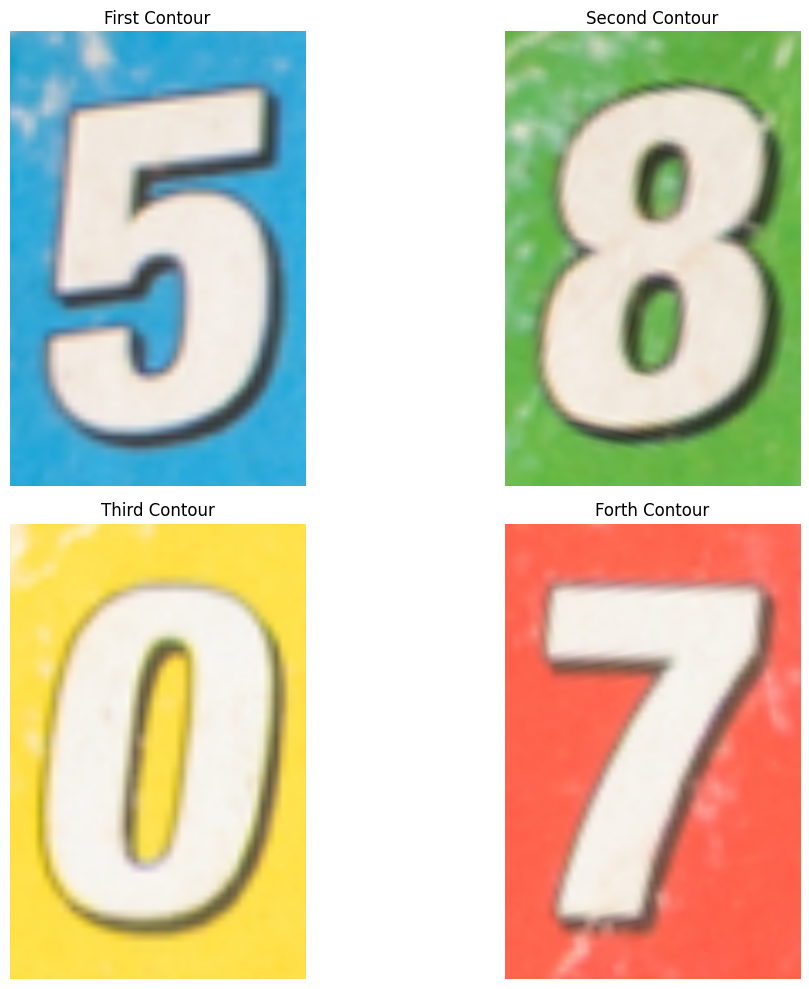

In [40]:
img = cv2.imread('train_images/L1000775.jpg')
gray = card_only_filter_blank(img)

valid_contours = detect_number_contours(gray)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

if len(valid_contours) > 4:
    normalized_1 = extract_and_normalize_card(img, valid_contours[8], extension=10)
    normalized_2 = extract_and_normalize_card(img, valid_contours[12], extension=10)
    normalized_3 = extract_and_normalize_card(img, valid_contours[2], extension=10)
    normalized_4 = extract_and_normalize_card(img, valid_contours[3], extension=10)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].imshow(normalized_1)
    axes[0, 0].set_title("First Contour")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(normalized_2)
    axes[0, 1].set_title(f"Second Contour")
    axes[0, 1].axis('off')

    axes[1, 0].imshow(normalized_3)
    axes[1, 0].set_title("Third Contour")
    axes[1, 0].axis('off')

    axes[1, 1].imshow(normalized_4)
    axes[1, 1].set_title(f"Forth Contour")
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

Then, for the classification of the color itself, we threshold the RGB values as in the `card_only_filter_blank`, to get rid of the white in the image, and we check the values of the mean for each RGB channel, and based on certain threshold we select the corresponding label.

In [ ]:
def classify_card_color(img_rgb):
    """
    Args:
        img_rgb: RGB normalized card image

    Returns:
        'r', 'y', 'g', 'b', 'black', or None
    """

    img = img_rgb.astype(np.uint8)

    valid_mask = card_only_filter_blank(img)
    valid_pixels = img[valid_mask]

    if len(valid_pixels) < 50:
        return None

    mean_rgb = valid_pixels.mean(axis=0)

    if mean_rgb.mean() < 60:
        return "black"

    dominant = np.argmax(mean_rgb)

    if dominant == 0:
        if abs(mean_rgb[0] - mean_rgb[1]) < 40:
            return "y"
        return "r"
    elif dominant == 1:
        return "g"
    elif dominant == 2:
        return "b"

    return None

print("Color of contour 3:" , classify_card_color(normalized_3))
print("Color of contour 4:" , classify_card_color(normalized_4))

Color of contour 2: y
Color of contour 3: r


----

### KNN Classifier

As seen before, we extended the dataset to include cropped reference images as well as rotated versions of these references, which allowed us to obtain a fairly large data cloud. For UNO cards, the shape of the contours should not vary too much (apart from slight camera angle changes and scale variations), meaning that every detected contour should remain relatively close to the cloud we generated.

Our idea is to use this cloud of Fourier descriptors as a reference space, and classify contours based on their distance to these points. This is essentially the definition of a KNN classifier. Since our data points are inhomogeneous in number (due to data curation and the limited number of available samples, e.g. 4 for colored cards and only one for wild and draw four), the most fair and also most effective choice was to use a single nearest neighbor. This usually leads to overfitting, but in our case the contour shapes do not vary significantly between cards, so overfitting is not a major concern.

However, we can still have detected contours that do not correspond to any card, due to noise or to holes inside some digits. In this case, we apply a rejection threshold based on distance: points that are too far from all references are rejected as outliers.

We found that a rejection threshold of around 8.5 is sufficient.

Below is the code for the classifier and a test on one image:

In [ ]:
class FourierDiscriminator:

    def __init__(
        self,
        n_neighbors=1,
        rejection_threshold=8.5
    ):

        self.scaler = StandardScaler()

        self.knn = KNeighborsClassifier(
            n_neighbors=n_neighbors
        )

        self.rejection_threshold = rejection_threshold

    def fit(
        self,
        datasets,
        test_size=0.2,
        random_state=42,
        verbose = False
    ):

        X, y = build_classifier_dataset(datasets)

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            stratify=y,
            random_state=random_state
        )
        X_train = self.scaler.fit_transform(X_train)
        X_test = self.scaler.transform(X_test)

        self.knn.fit(X_train, y_train)

        y_pred = self.knn.predict(X_test)
        if verbose:
            print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
            print(f"Macro F1 : {f1_score(y_test, y_pred, average='macro'):.4f}\n")
            print(classification_report(y_test, y_pred))

    def predict(self, descriptor):

        descriptor = np.asarray(descriptor).reshape(1, -1)
        descriptor = self.scaler.transform(descriptor)

        distances, _ = self.knn.kneighbors(descriptor)
        mean_distance = distances.mean()

        if mean_distance > self.rejection_threshold:
            return "None", mean_distance

        prediction = self.knn.predict(descriptor)[0]

        return prediction, mean_distance

In [ ]:
classifier = FourierDiscriminator(n_neighbors=1, rejection_threshold=8.5)
classifier.fit(datasets)

prediction: ['eight', 'six-nine', 'zero', 'eight', 'zero', 'three', 'eight', 'six-nine', 'three', 'None', 'seven', 'seven', 'zero', 'None', 'None', 'None', 'zero', 'six-nine', 'six-nine', 'plus', 'two', 'two', 'plus', 'zero', 'zero', 'None', 'None', 'three', 'None', 'six-nine', 'zero', 'six-nine', 'None', 'zero', 'six-nine', 'two', 'six-nine']


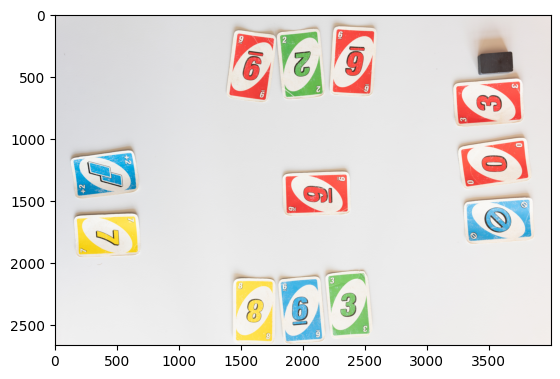

In [42]:
img_test = cv2.imread('train_images/L1000772.jpg', cv2.IMREAD_COLOR_RGB)
plt.imshow(img_test)
contours = detect_number_contours(card_only_filter_blank(img_test).astype(np.uint8))
descriptors, centers, angles = fourier_descriptors(contours)

card_types = []
for idx, descriptor in enumerate(descriptors):

    descriptor = np.asarray(descriptor).flatten()
    card_type, dist = classifier.predict(descriptor)
    card_types.append(card_type)
print(f'prediction: {card_types}')

You might have noticed that there are too many outputs from the classifier, with some repetitions. This is due to the fact that each card produces two contours, and in some cases certain contours also bypass the classification and area filtering steps. We therefore apply additional correction steps, which will be explained in the following sections.

---

### Assigning cards to players and center

We can easily assign cards to players by splitting the image into five regions corresponding to p1, p2, p3, p4, and the center. We first load the training images:

In [23]:
project_root = Path.cwd()
folder_train = project_root / "train_images"

images_train = []
for path in glob(os.path.join(folder_train, "*")):
    img = cv2.imread(path)

    if img is not None:
        images_train.append(img)

Then we segment and filter out the white background, as a simple way to better highlight the boundaries:

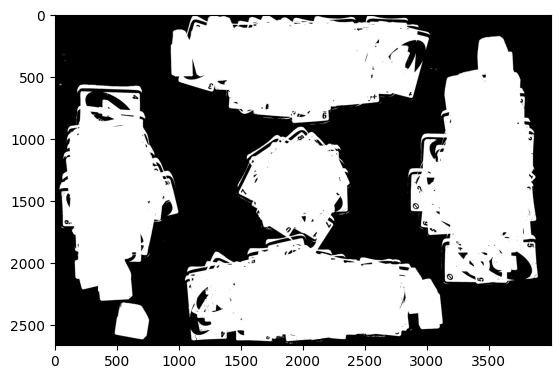

In [24]:
white_b_train = [img for img in images_train if np.mean(img)>180]
segmented_images_train = np.array([card_only_filter_blank(img)
                          for img in white_b_train])
sum_train = np.sum(segmented_images_train, axis=0)
normalized_sum_train = (sum_train*255)/np.max(sum_train)
border_train = sum_train>0
plt.imshow(border_train, cmap="gray")

As can be seen, we can clearly delimit the player areas, assuming that these regions remain consistent across all images:

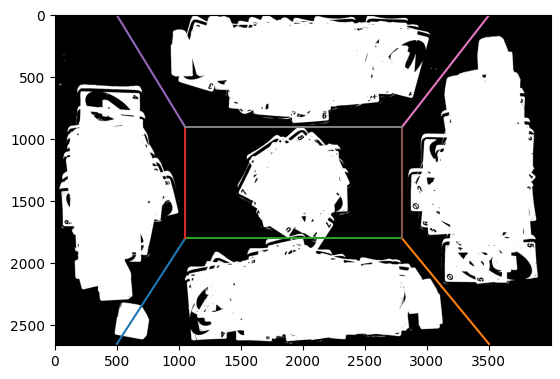

In [25]:
plt.imshow(border_train, cmap="gray")
plt.plot([500,1050],[2650,1800])
plt.plot([3500,2800],[2650,1800])
plt.plot([1050,2800], [1800,1800])
plt.plot([1050,1050],[1800,900])
plt.plot([500,1050],[0,900])
plt.plot([2800,2800],[1800,900])
plt.plot([2800,3500],[900,0])
plt.plot([1050,2800], [900,900])

This allows us to manually segment the image with the function below:

In [26]:
def assign_card2player(center):

    top_l = lambda x: ((1800-2662)/(1050-500))*(x-500) + 2662
    top_r = lambda x: ((1800-2662)/(2800-3500))*(x-3500) + 2662
    bot_l = lambda x: ((900-0)/(1050-500))*(x-500)
    bot_r = lambda x: ((0-900)/(3500-2800))*(x-2800) + 900
    
    if center[1] < 900 and center[1] < bot_l(center[0]) and center[1] < bot_r(center[0]):
        return 'p3'
    elif center[0] < 1050 and center[1] > bot_l(center[0]) and center[1] < top_l(center[0]):
        return 'p4'
    elif center[1] > 1800 and center[1] > top_l(center[0]) and center[1] > top_r(center[0]):
        return 'p1'
    elif center[0] > 2800 and center[1] > bot_r(center[0]) and center[1] < top_r(center[0]):
        return 'p2'
    else:
        return 'center'

---

### Correcting assignment

We first designed a function that removes duplicate detections caused by cards having two contours, and therefore lead to multiple detections of the same UNO card.

Two predictions are considered duplicates if they have:
- the same predicted class
- the same color
- centers closer than `pair_distance_target` (530 px)

When duplicates are found, only the first prediction is kept.

This mainly removes:
- inner + outer contour detections
- fragmented contour duplicates
- multiple detections of the same card symbol

In [27]:
def deduplicate_predictions(
    predictions,
    pair_distance_target=530
):
    """
    Keep only one prediction when:
    - same class
    - same color
    - same angle
    - AND centers are either:
        * extremely close (duplicate)
        * OR separated by ~480 +/- margin
    """

    kept = []

    for pred in predictions:

        keep = True

        center_a = np.array(pred["center"])
        angle_a = pred["angle"]
        class_a = pred["class"]
        color_a = pred["color"]

        for existing in kept:

            center_b = np.array(existing["center"])
            angle_b = existing["angle"]
            class_b = existing["class"]
            color_b = existing["color"]

            same_class = class_a == class_b
            same_color = color_a == color_b

            angle_diff = abs(angle_a - angle_b)
            angle_diff = min(angle_diff, 360 - angle_diff)

            #deprecated (does not work well)
            #same_angle = angle_diff < angle_thresh
            same_angle = True

            dist = np.linalg.norm(center_a - center_b)

            close_duplicate = (
                dist < pair_distance_target
            )
            
            if (
                same_class
                and same_color
                and same_angle
                and close_duplicate
            ):
                keep = False
                break

        if keep:
            kept.append(pred)

    return kept

Then we designed a function that detects UNO card symbols using the previously defined components and applies a series of post-processing corrections, as well as duplicate removal, and returns the overall prediction. The full pipeline is as follows:

- applies scene-dependent filtering (white background vs leaf background)
- extracts symbol contours
- computes Fourier descriptors
- predicts symbol class using the KNN classifier
- extracts card color and player assignment
- resolves wild ↔ zero confusion using card color
- removes invalid black card detections
- merges plus + two/four → plus2/plus4 cases
- filters out false zero detections near six/eight/nine of the same color (since these can correspond to inner pictogram holes being misclassified as zero)
- removes duplicate detections (deduplicate_predictions)

The function returns a cleaned list of detected cards containing:

- class
- color
- player
- center position
- contour angle
- classifier distance

The additional returned parameters are mainly used for debugging purposes.

In [28]:
def classify_image(
    img,
    classifier,
    pair_distance_target=530,
    distance_threshold_plus=50
):
    
    mean_value = img.mean()

    if mean_value > 200:
        gray = card_only_filter_blank(img)
    else:
        gray = card_only_filter_leaf(img)
    contours = detect_number_contours(gray)
    descriptors, centers, angles = fourier_descriptors(contours)

    raw_predictions = []

    for idx, descriptor in enumerate(descriptors):

        descriptor = np.asarray(descriptor).flatten()
        card_type, dist = classifier.predict(descriptor)
        if card_type == "None":
            continue

        normalized_card = extract_and_normalize_card(
            img,
            contours[idx],
            extension=10
        )

        if card_type == "six-nine":
            # TODO: proper discrimination
            card_type = "six"

        color = classify_card_color(normalized_card)
        player = assign_card2player(centers[idx])

        if player is None:
            continue
        if color == "black" and card_type == 'zero':
            card_type = 'wild'
        if color != "black" and card_type == 'wild':
            card_type = 'zero'
        if color == "black" and card_type not in ["wild", "plus"]:
            continue

        raw_predictions.append({
            "class": card_type,
            "color": color,
            "mean_color": cv2.mean(normalized_card)[:3],
            "player": player,
            "center": centers[idx],
            "angle": angles[idx],
            "distance": dist
        })

    plus_cards = [
        p for p in raw_predictions
        if p["class"] == "plus"
    ]

    non_plus = [
        p for p in raw_predictions
        if p["class"] != "plus"
    ]

    final_predictions = []

    used_non_plus = set()

    for plus in plus_cards:

        plus_center = np.array(plus["center"])

        nearest = None
        nearest_dist = float("inf")

        nearest_type = None

        for i, p in enumerate(non_plus):

            if i in used_non_plus:
                continue
            if p["class"] not in ["two", "four"]:
                continue

            d = np.linalg.norm(
                np.array(p["center"]) - plus_center
            )
            if d < nearest_dist and d < distance_threshold_plus:
                nearest_dist = d
                nearest = i
                nearest_type = p["class"]

        plus_fixed = dict(plus)
        if nearest_type == "four":
            plus_fixed["class"] = "plus4"
        elif nearest_type == "two":
            plus_fixed["class"] = "plus2"

        #default
        else:
            plus_fixed["class"] = "plus2"

        final_predictions.append(plus_fixed)
        if nearest is not None:
            used_non_plus.add(nearest)

    for i, p in enumerate(non_plus):
        if i in used_non_plus:
            continue
        final_predictions.append(p)

    filtered_predictions = []
    for i, p in enumerate(final_predictions):

        if p["class"] != "zero":
            continue

        zero_center = np.array(p["center"])

        remove_zero = False

        for q in final_predictions:

            if q["class"] not in ["six", "eight", "nine"]:
                continue

            if q["color"] != p["color"]:
                continue

            d = np.linalg.norm(
                zero_center - np.array(q["center"])
            )

            if d < (2/3)*pair_distance_target:
                remove_zero = True
                break

        if not remove_zero:
            filtered_predictions.append(p)

    # keep everything that is NOT zero (including 6/8/9 always)
    for p in final_predictions:
        if p["class"] != "zero":
            filtered_predictions.append(p)

    final_predictions = filtered_predictions
    
    final_predictions = deduplicate_predictions(
        final_predictions,
        pair_distance_target=pair_distance_target
    )

    return final_predictions

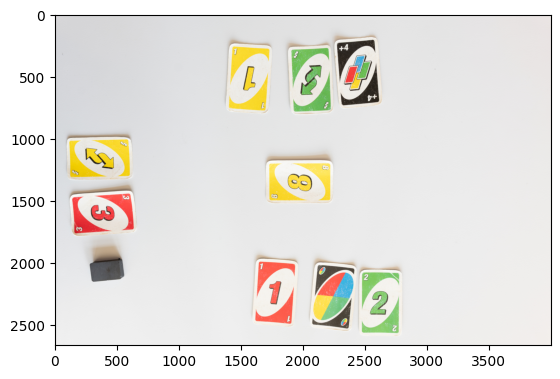

In [29]:
plt.imshow(img_white)

In [30]:
classify_image(img_white, classifier=classifier)

[{'class': 'zero',
  'color': 'y',
  'mean_color': (158.40298412698414, 152.63732804232805, 124.86579894179894),
  'player': 'p1',
  'center': array([2325.80121527, 2476.94615796]),
  'angle': -0.6089952094539746,
  'distance': 7.487705769945626},
 {'class': 'plus2',
  'color': 'black',
  'mean_color': (111.71530158730158, 104.63254497354498, 96.71767724867725),
  'player': 'p3',
  'center': array([2571.45085791,  664.084211  ]),
  'angle': -1.6987557800944706,
  'distance': 5.099349363736861},
 {'class': 'skip',
  'color': 'y',
  'mean_color': (139.57754497354497, 133.15491534391535, 109.6968783068783),
  'player': 'p1',
  'center': array([2326.02070265, 2476.49680221]),
  'angle': -1.433356383629738,
  'distance': 5.479848529941499},
 {'class': 'two',
  'color': 'g',
  'mean_color': (170.3372275132275, 207.155708994709, 157.96623809523808),
  'player': 'p1',
  'center': array([2732.13837721, 2526.66211052]),
  'angle': -1.8572129810237372,
  'distance': 7.151939255928061},
 {'class':

---
### Finding the active player

As well as for the rest of this project, we decided to use classical methods for finding the token that signals who the active player is, as we believe this kind of procedures are more explainable and visually understandable.

For this task, we assumed that there were only two types of background: Completely white and the noisy leave pattern. With this in mind, we curated a color filtering to keep only the regions of the images that could possibly be the token we were looking for.

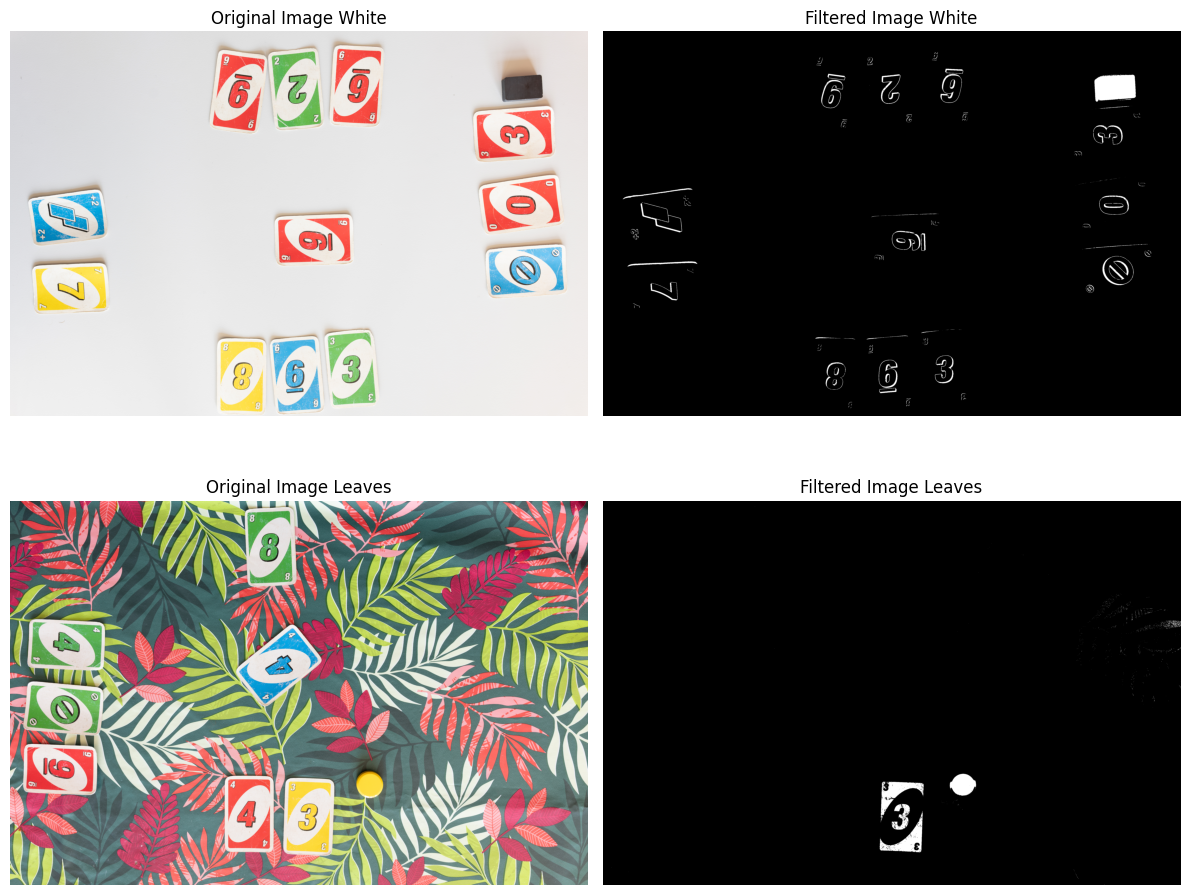

In [31]:
img = cv2.imread('train_images/L1000772.jpg', cv2.IMREAD_COLOR_RGB)
img_leaves = cv2.imread('train_images/L1000909.jpg', cv2.IMREAD_COLOR_RGB)

img_filter_white = apply_rgb_threshold(img, (0,150), (0,150), (0,150))

img_filter_leaves = apply_rgb_threshold(img_leaves, (200,255), (200,255), (0,80))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img)
axes[0, 0].set_title("Original Image White")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_filter_white, cmap='gray')
axes[0, 1].set_title(f"Filtered Image White")
axes[0, 1].axis('off')

axes[1, 0].imshow(img_leaves)
axes[1, 0].set_title("Original Image Leaves")
axes[1, 0].axis('off')

axes[1, 1].imshow(img_filter_leaves, cmap='gray')
axes[1, 1].set_title(f"Filtered Image Leaves")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

Once the images were filtered, we cropped them into separate regions (different from those used for card assignment) corresponding to each player, and applied a morphological opening to retain only the token while removing remaining artifacts.

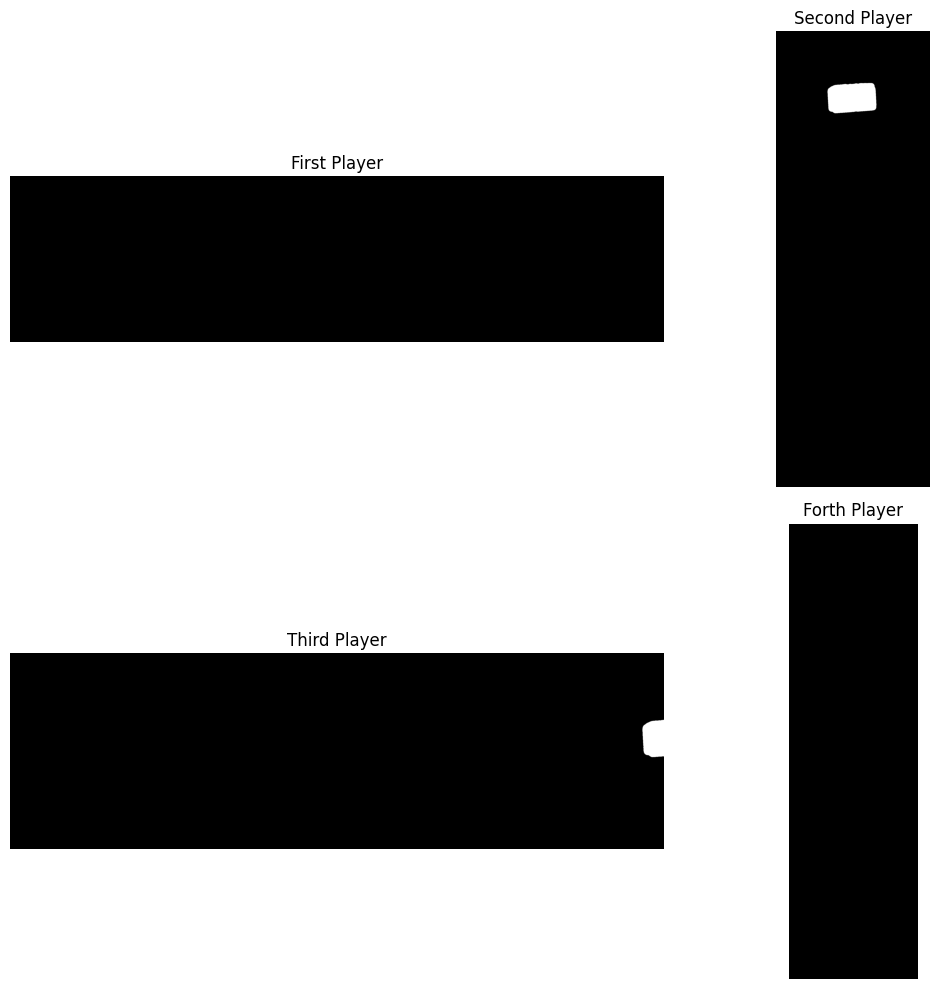

In [32]:
img_1 = apply_opening(img_filter_white[1900:,500:3500], 20)
img_2 = apply_opening(img_filter_white[:,3100:], 20)
img_3 = apply_opening(img_filter_white[:900,500:3500], 20)
img_4 = apply_opening(img_filter_white[:,:750], 20)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_1, cmap='gray')
axes[0, 0].set_title("First Player")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_2, cmap='gray')
axes[0, 1].set_title(f"Second Player")
axes[0, 1].axis('off')

axes[1, 0].imshow(img_3, cmap='gray')
axes[1, 0].set_title("Third Player")
axes[1, 0].axis('off')

axes[1, 1].imshow(img_4, cmap='gray')
axes[1, 1].set_title(f"Forth Player")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

As the crops overlap, it is posible that more than one end up having part of the token, so to determine who the starting player is, we count the number of pixels of token in each crop, and the one with the most is chosen as the active player.

Of course, this crops are predetermined, and while they usually cover most of the space a player takes on the table, it is possible that the token could be outside of this part of the image, leading to an error, but as it works for the great majority of cases, we believe that this solution is good enough without having to overcomplicate it.

The whole function ends up like this: 

In [33]:
def find_active_player(img):
    mean_value = img.mean()
    
    n = []

    if mean_value > 200:
        img_filter = apply_rgb_threshold(img, (0,150), (0,150), (0,150))

    else:
        img_filter = apply_rgb_threshold(img, (200,255), (200,255), (0,80))
    img_1 = apply_opening(img_filter[1900:,500:3500], 20)
    img_2 = apply_opening(img_filter[:,3100:], 20)
    img_3 = apply_opening(img_filter[:900,500:3500], 20)
    img_4 = apply_opening(img_filter[:,:750], 20)

    n.append(sum(img_1[img_1 == True]))
    n.append(sum(img_2[img_2 == True]))
    n.append(sum(img_3[img_3 == True]))
    n.append(sum(img_4[img_4 == True]))

    player = np.argmax(n) + 1

    return "p"+str(player)

---
## Main failure points

As it can be imagined, classical methods cannot completely solve a task like this, at least with the tools we have used. There are a series of issues that cannot be avoided and lower the overall performance of our pipeline.

* Six and nine discrimination: Since we are using the rotation-invariant contours of the numbers as a mean to classify them, the features we obtain for the number 6 and the number 9 are nearly identical. We tried implementing a function to difference them based on the bar they have, but it was too inconsistent, so we ended up just describing all of them as 6, causing a decrease in accuracy.
* Holes detected as valid cards: when the center of certain cards is visible, our pipeline can detect the holes in numbers such as 0, 6, 8, or 9 as independent contours, and this contours can end up being classified as 0, even after filtering.
* wild, zero, skip discrimination: Similarly to six and nine discrimination, wild, skip and zero are very close to each other in the descriptor cloud. While wild card can be discriminated by color, skip is often confused with zero, and we did not find anyway to make meaningful corrections.

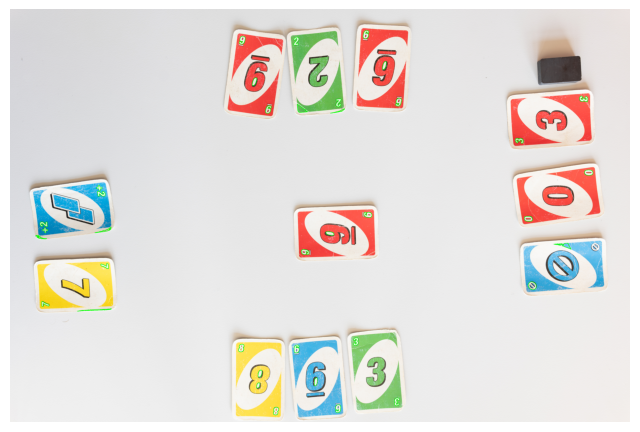

In [34]:
test_img = img
filter_img = card_only_filter_blank(test_img)
valid_contours_test = detect_number_contours(filter_img)
_ = plot_contours(test_img, valid_contours_test)

* Light variation: as our segmentation is based on RGB and HSV filtering, it can be highly dependent on changes in the light of the scene, leading to our classification working well in some images and quite poorly on others where the filters are not as good.

---

### Full pipeline

The last step is to develop the full pipeline, from a folder containing images to the final CSV predictions. The first part is to map our predictions to the correct format expected for the CSV output (e.g. `{color}_{card_class}`):

In [43]:
def format_card(card_class, color):
    """
    Convert prediction into CSV card format.
    """
    mapping = {
        "plus2": "draw_2",
        "plus4": "draw_4",
        "reverse": "reverse",
        "skip": "skip",
        "wild": "wild",
        "zero": "0",
        "one": "1",
        "two": "2",
        "three": "3",
        "four": "4",
        "five": "5",
        "six": "6",
        "seven": "7",
        "eight": "8",
        "nine": "9",
    }

    if card_class in mapping:

        value = mapping[card_class]

        if card_class in ["wild", "plus4"]:
            return value

        return f"{color}_{value}"
    return f"{color}_{card_class}"

For each image, we compute the predictions and assign the corresponding cards to each player and to the center:

In [ ]:
def find_cards_per_player(img, classifier):

    cards = {"p1": [], "p2": [], "p3": [], "p4": [], "center": []}
        
    predictions = classify_image(img, classifier)

    for pred in predictions:
        player = pred["player"]
        color = pred["color"]
        number = pred["class"]

        string = format_card(number, color)

        cards[player].append(string)

    for key in cards:
        if len(cards[key]) == 0:
            cards[key] = ["EMPTY"]

    return cards

Finally, we extract the player cards and build a table in the correct format using `pandas`. We use the `find_active_player` function to identify the active player for each image and include it in the table. We then simply use the method `to_csv` of the dataframe to save the final results.

In [ ]:
def classify_folder(img_folder, classifier):

    result = pd.DataFrame(columns=["image_id","center_card","active_player","player_1_cards","player_2_cards","player_3_cards","player_4_cards"])
    img_folder = Path(img_folder)
    
    for path in tqdm(img_folder.glob("*.jpg")):
        original_img = cv2.imread(str(path))
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        row = []
        player_cards = find_cards_per_player(original_img, classifier)
        image_id = path.stem
        center_card = player_cards["center"][0]
        active_player = find_active_player(original_img)
        player_1_cards = ";".join(player_cards["p1"])
        player_2_cards = ";".join(player_cards["p2"])
        player_3_cards = ";".join(player_cards["p3"])
        player_4_cards = ";".join(player_cards["p4"])

        row.append(image_id)
        row.append(center_card)
        row.append(active_player)
        row.append(player_1_cards)
        row.append(player_2_cards)
        row.append(player_3_cards)
        row.append(player_4_cards)

        result.loc[len(result)] = row
    return result

def save_result(result, path="submission.csv"):
    result.to_csv(path, index=False)

---

### Conclusion

Overall, we managed to build a fully classical computer vision pipeline for UNO card detection and classification using segmentation, contour extraction, Fourier descriptors, and KNN classification. While classical methods have clear limitations, especially for lighting variation and visually similar classes, we were able to obtain relatively robust results preprocessing, dataset curation, prediction corrections and duplicate removal.

Our pipeline slightly outperformed the TA classical baseline, reaching an F1-score of 0.62 compared to 0.57, showing that the choices we made had a positive impact on the final performance.

Overall, we are satisfied with both the results and the way we approached the problem. There is still room for improvement, especially for class ambiguity, robustness to lighting conditions, and handling difficult edge cases, which also shows that we have a correct approach overall.